In [25]:
!pip install xgboost



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
import pandas as pd
import numpy as np
import os
import json
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [27]:
DATA_PATH = '../backend/data/AQ of adoloscents - Sheet.csv'

df = pd.read_csv(DATA_PATH)

if 'Q1' not in df.columns:
    question_cols = df.columns[0:9]
    rename_map = {col: f'Q{i+1}' for i, col in enumerate(question_cols)}
    df = df.rename(columns=rename_map)

# Engineer Target_Category
if 'Target_Category' not in df.columns:
    def categorize_aq(score):
        if score < 2.5: return 0      # Low
        elif score < 3.5: return 1    # Medium
        else: return 2                # High
    df['Target_Category'] = df['AQ'].apply(categorize_aq)

features = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10']
X = df[features]
y = df['Target_Category']

print(f"Data Loaded. Shape: {df.shape}")
df[features + ['Target_Category']].head()

Data Loaded. Shape: (122, 16)


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Target_Category
0,4,5,4,4,5,4,3,4,5,4,2
1,4,4,3,4,4,4,4,4,4,5,2
2,5,5,5,5,3,3,3,2,5,3,2
3,5,5,4,5,5,5,5,5,5,4,2
4,4,4,3,5,4,4,5,4,4,3,2


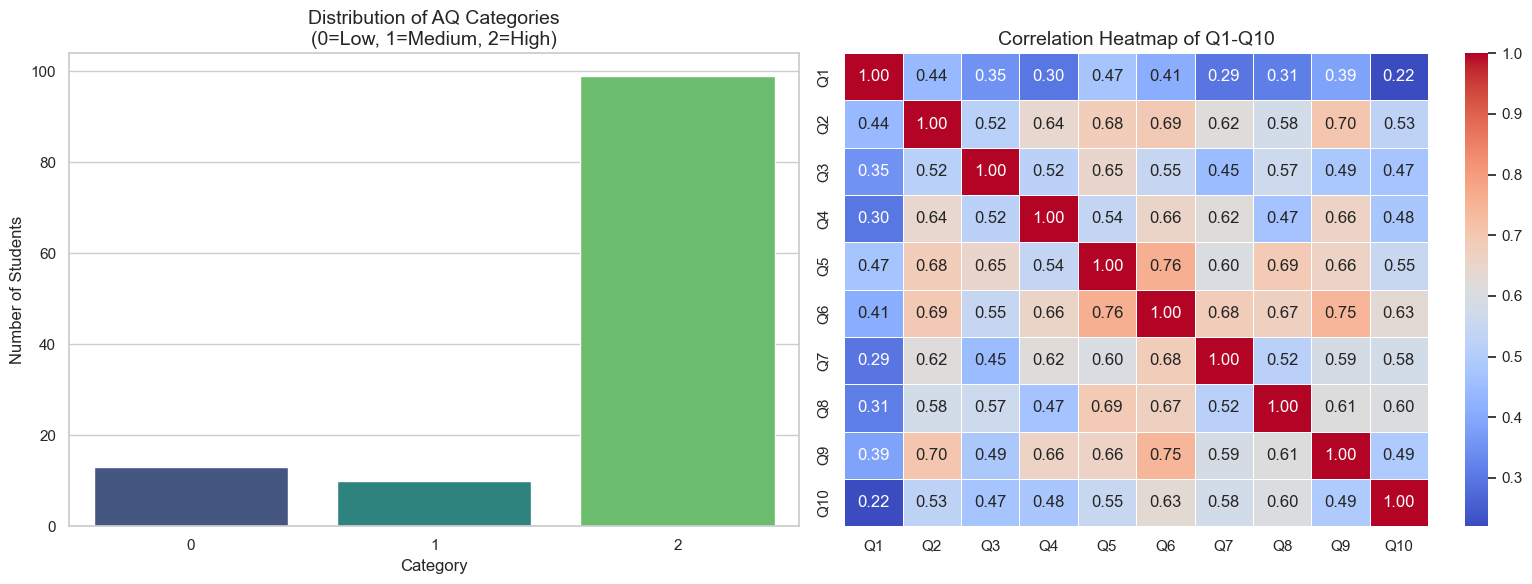

In [28]:
# Cell 3: EDA - Understanding the Data Relationships

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Distribution of Target Categories
sns.countplot(data=df, x='Target_Category', palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of AQ Categories\n(0=Low, 1=Medium, 2=High)', fontsize=14)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Students')

# Plot 2: Correlation Heatmap of Questions
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=axes[1])
axes[1].set_title('Correlation Heatmap of Q1-Q10', fontsize=14)

plt.tight_layout()
plt.show()

In [29]:
# Cell 4: Train-Test Split and Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_scaled_all   = scaler.transform(X)

# Convert to DataFrame to preserve feature names (avoids XGBoost warnings)
X_train_df = pd.DataFrame(X_train_scaled, columns=features)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=features)
X_all_df   = pd.DataFrame(X_scaled_all,   columns=features)

print("Data Split and Scaled!")
print(f"Training set: {X_train_df.shape[0]} samples")
print(f"Testing set : {X_test_df.shape[0]} samples")

Data Split and Scaled!
Training set: 97 samples
Testing set : 25 samples


In [30]:
# Cell 5: Train XGBoost Model and Calculate Metrics
xgb_model = XGBClassifier(
    n_estimators=150,        # Number of boosting rounds
    max_depth=8,             # Max depth of each tree
    learning_rate=0.03,       # Step size shrinkage
    subsample=0.8,           # Fraction of samples per tree
    colsample_bytree=0.8,    # Fraction of features per tree
    use_label_encoder=False,
    eval_metric='mlogloss',  # Multi-class log loss
    random_state=42
)
xgb_model.fit(X_train_df, y_train)

y_pred  = xgb_model.predict(X_test_df)
y_proba = xgb_model.predict_proba(X_test_df)

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

try:
    auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
except ValueError:
    auc_score = 0.0

cv_results = cross_validate(xgb_model, X_all_df, y, cv=5, scoring=['accuracy'])
cv_mean = cv_results['test_accuracy'].mean()
cv_std  = cv_results['test_accuracy'].std()

print(f" Accuracy : {acc:.4f}")
print(f" F1 Score : {f1:.4f}")
print(f" AUC-ROC  : {auc_score:.4f}")
print(f" CV Mean  : {cv_mean:.4f} (± {cv_std:.4f})")
print(f" Estimators: {xgb_model.n_estimators}")

 Accuracy : 0.9600
 F1 Score : 0.9635
 AUC-ROC  : 1.0000
 CV Mean  : 0.9017 (± 0.0422)
 Estimators: 150


In [31]:
print("boost predictions:")
print(y_pred[:20])

boost predictions:
[2 2 2 2 2 2 0 2 2 0 2 2 1 2 1 2 2 2 2 1]


[[ 3  0  0]
 [ 0  2  0]
 [ 0  1 19]]
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         3
      Medium       0.67      1.00      0.80         2
        High       1.00      0.95      0.97        20

    accuracy                           0.96        25
   macro avg       0.89      0.98      0.92        25
weighted avg       0.97      0.96      0.96        25



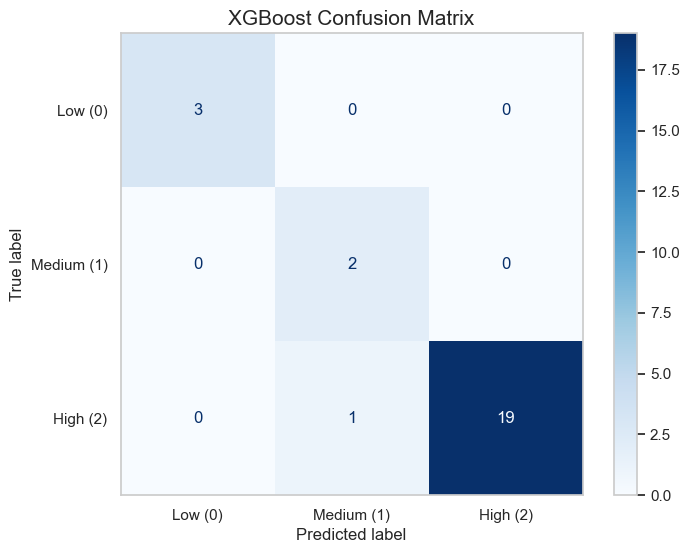

In [32]:
# Cell 6: Confusion Matrix
from sklearn.metrics import classification_report

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low (0)', 'Medium (1)', 'High (2)']
)
print(cm)
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))


fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('XGBoost Confusion Matrix', fontsize=15)
plt.grid(False)
plt.show()

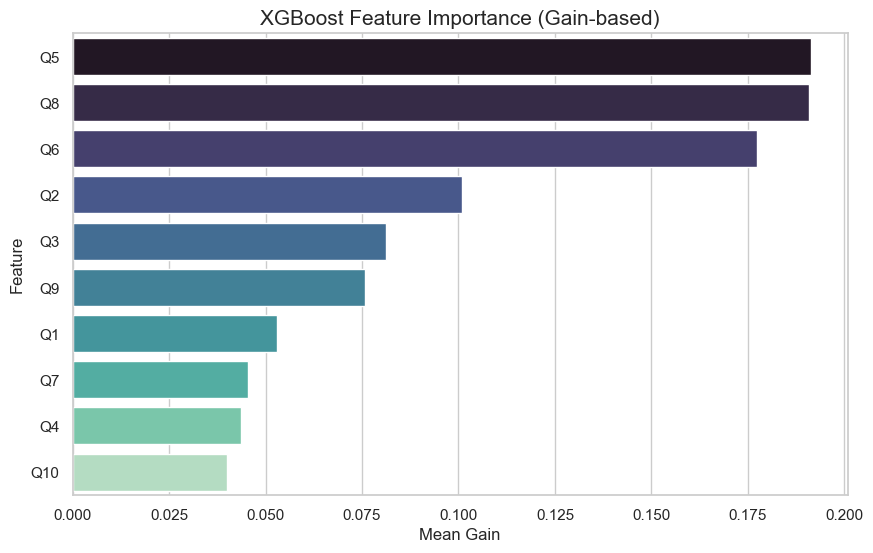

Feature  Importance
     Q5    0.191288
     Q8    0.190854
     Q6    0.177478
     Q2    0.101013
     Q3    0.081344
     Q9    0.075898
     Q1    0.052853
     Q7    0.045556
     Q4    0.043758
    Q10    0.039957


In [33]:
# Cell 7: Feature Importance (Native - XGBoost gain-based)
# XGBoost provides three importance types:
#   'weight'  - how many times a feature is used in splits
#   'gain'    - average gain of splits using the feature (most informative)
#   'cover'   - average coverage of splits using the feature

from xgboost import plot_importance

feat_imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_   # uses 'gain' by default
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='mako')
plt.title('XGBoost Feature Importance (Gain-based)', fontsize=15)
plt.xlabel('Mean Gain')
plt.show()

print(feat_imp_df.to_string(index=False))

SHAP Summary Plot (Global Impact)


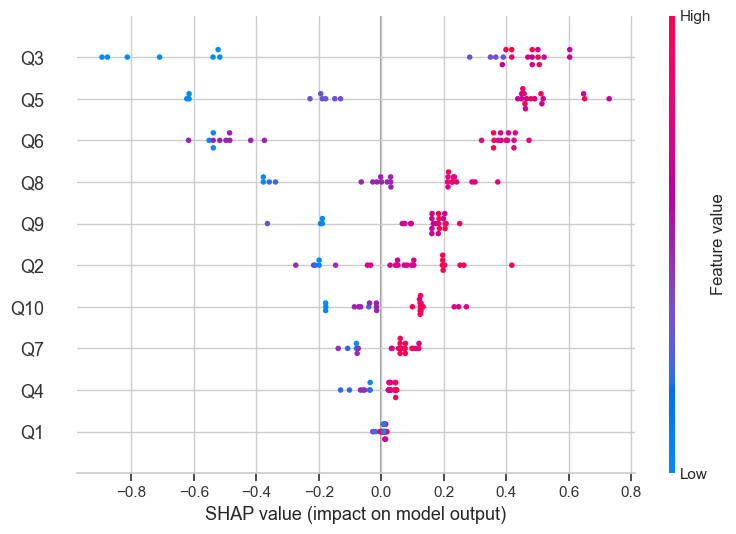

In [34]:
# Cell 8: SHAP Values (TreeExplainer — native & fast for XGBoost)
# TreeExplainer is fully picklable and does NOT require background samples.
explainer = shap.TreeExplainer(xgb_model)
shap_vals = explainer.shap_values(X_test_df)

print("SHAP Summary Plot (Global Impact)")

# shap_vals shape: (n_samples, n_features, n_classes) for multi-class XGBoost
if isinstance(shap_vals, list):
    target_idx = len(shap_vals) - 1
    plot_data  = shap_vals[target_idx]
else:
    if len(np.array(shap_vals).shape) == 3:
        plot_data = np.array(shap_vals)[:, :, -1]
    else:
        plot_data = shap_vals

shap.summary_plot(plot_data, X_test_df, feature_names=features)

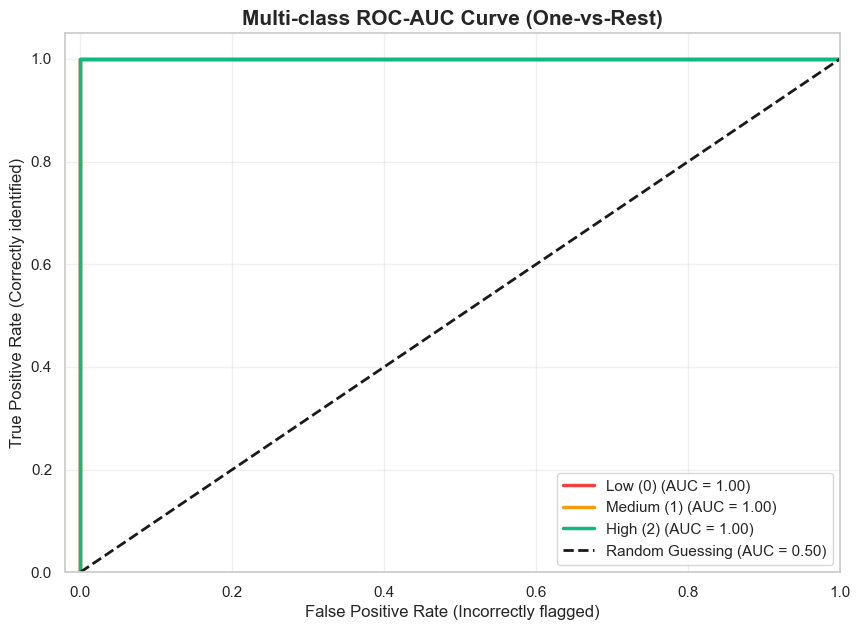

In [35]:
# Cell 9: ROC-AUC Curve (Multi-Class One-vs-Rest)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes  = y_test_bin.shape[1]

class_names = ['Low (0)', 'Medium (1)', 'High (2)']
colors = ['#ef4444', '#f59e0b', '#10b981']

plt.figure(figsize=(10, 7))

y_proba = xgb_model.predict_proba(X_test_df)

for i in range(n_classes):
    if i in xgb_model.classes_ and sum(y_test_bin[:, i]) > 0:
        prob_col_idx = list(xgb_model.classes_).index(i)
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba[:, prob_col_idx])
        auc_i = auc(fpr_i, tpr_i)
        plt.plot(fpr_i, tpr_i, color=colors[i], lw=2.5,
                 label=f'{class_names[i]} (AUC = {auc_i:.2f})')
    else:
        print(f"Skipping '{class_names[i]}' - Class absent in test set.")

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing (AUC = 0.50)')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Incorrectly flagged)', fontsize=12)
plt.ylabel('True Positive Rate (Correctly identified)', fontsize=12)
plt.title('Multi-class ROC-AUC Curve (One-vs-Rest)', fontsize=15, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()

In [36]:
# Cell 10: Export Data
MODELS_DIR = '../backend/ml_models/xgboost'
os.makedirs(MODELS_DIR, exist_ok=True)

# 1. Save core ML components
joblib.dump(xgb_model, os.path.join(MODELS_DIR, 'xgboost_model.pkl'))
joblib.dump(scaler,    os.path.join(MODELS_DIR, 'scaler.pkl'))
joblib.dump(X_train_df,   os.path.join(MODELS_DIR, 'X_train.pkl'))

# 2. Save SHAP TreeExplainer — fully picklable (no KernelExplainer issues)
joblib.dump(explainer, os.path.join(MODELS_DIR, 'shap_explainer.pkl'))


# SHAP-based feature importance (mean |SHAP| across all classes, with rank)
def _mean_abs_shap(sv):
    if isinstance(sv, list):
        return np.mean([np.mean(np.abs(c), axis=0) for c in sv], axis=0)
    arr = np.array(sv)
    if arr.ndim == 3:
        return np.mean(np.abs(arr), axis=(0, 2))
    return np.mean(np.abs(arr), axis=0)

global_shap_importance = _mean_abs_shap(shap_vals)
fi_ranked = sorted(
    zip(features, global_shap_importance.tolist()),
    key=lambda x: x[1], reverse=True
)
feature_importance_data = [
    {"feature": f, "importance": round(v, 10), "rank": r + 1}
    for r, (f, v) in enumerate(fi_ranked)
]
with open(os.path.join(MODELS_DIR, 'feature_importance.json'), 'w') as fp:
    json.dump(feature_importance_data, fp, indent=4)
print("Saved: feature_importance.json  (SHAP-based, ranked)")


# 4. Append metrics to shared evaluation_metrics.json
metrics_file = os.path.join(MODELS_DIR, 'evaluation_metrics.json')
metrics_data = []

if os.path.exists(metrics_file):
    with open(metrics_file, 'r') as f:
        try:
            metrics_data = json.load(f)
        except json.JSONDecodeError:
            pass

metrics_data = [m for m in metrics_data if m['model_name'] != 'XGBoost']

metrics_data.append({
    'model_name': 'XGBoost',
    # NOTE: If these values match Random Forest exactly, the notebook was
    # not re-run after copy-pasting. Use Kernel → Restart & Run All.
    'accuracy':   round(float(acc), 4),
    'f1_score':   round(float(f1),  4),
    'auc_roc':    round(float(auc_score), 4),
    'cv_mean':    round(float(cv_mean), 4),
    'cv_std':     round(float(cv_std),  4)
})

with open(metrics_file, 'w') as f:
    json.dump(metrics_data, f, indent=4)

print("SUCCESS: XGBoost Model, Scaler, SHAP Explainer, Feature Importance JSON, and Metrics saved!")

Saved: feature_importance.json  (SHAP-based, ranked)
SUCCESS: XGBoost Model, Scaler, SHAP Explainer, Feature Importance JSON, and Metrics saved!
